**Task 3: Exploiting Correlations**

In [1]:
# Loading necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from numpy import linalg as LA
from fredapi import Fred
sns.set_theme()

**Generating Uncorrelated Random Numbers**

In [2]:
# Generating 5 uncorrelated Gaussian random variables.
np.random.seed(1) 
# Setting the path for reproducible random numers (pseudorandom numbers)
z = np.random.randn(100, 5) 
# Generates a numpy array of 100 x 5 standard normal random numbers
z = pd.DataFrame(z) 
z.head() 
# .head() does not work with numpy array, it works with pandas dataframe.
means = [0.01, .015, .005, -.002, .007] # vector of means
stdev = [.02, .025, .015, .01, .03] # vector of standard deviations
y = pd.DataFrame(means + z * stdev) 
# scaling and shifting to get final random numbers
y.columns = ['1-Month', '3-Months', '1-Year', '3-Years', '5-Years']
# Each column represents a particular government yield, rows 
# represent time (first day, second day etc) and entries in the cell 
# represent the daily yield change percentages.
y.head() 

,1-Month,3-Months,1-Year,3-Years,5-Years
0,0.042487,-0.000294,-0.002923,-0.012730,0.032962
1,-0.036031,0.058620,-0.006418,0.001190,-0.000481
2,0.039242,-0.036504,0.000164,-0.005841,0.041013
3,-0.011998,0.010689,-0.008168,-0.001578,0.024484
4,-0.012012,0.043618,0.018524,0.003025,0.034026


**Estimating Covariance Matrix and Plotting Heatmap**

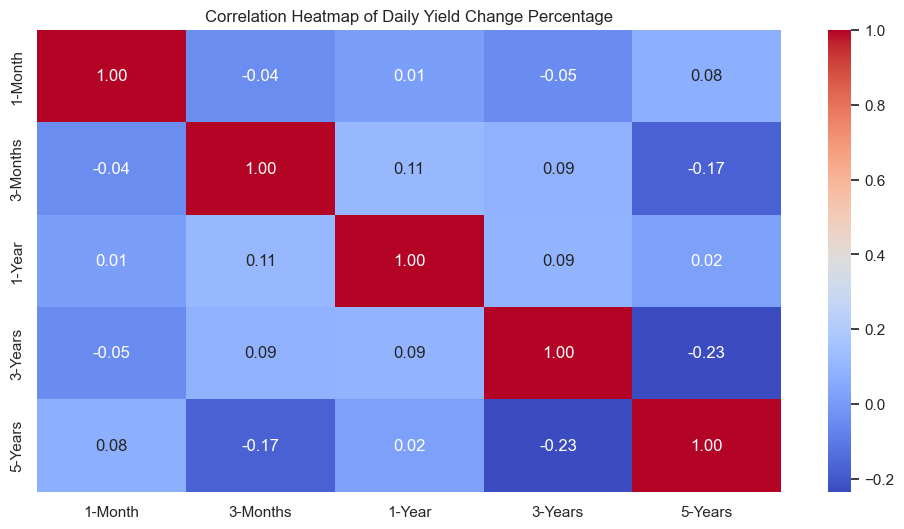

In [3]:
# Calculatin of covariance matrix and plotting the heatmap.
corr_mat = y.corr()
plt.figure(figsize = (12, 6))
sns.heatmap(corr_mat, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap of Daily Yield Change Percentage')
plt.show() 
# Heatmap has warm colors along the diagonal and all off 
# diagonal have cool colors

In [4]:
corr_mat.head()

,1-Month,3-Months,1-Year,3-Years,5-Years
1-Month,1.000000,-0.042596,0.013182,-0.049627,0.078421
3-Months,-0.042596,1.000000,0.108222,0.087759,-0.171626
1-Year,0.013182,0.108222,1.000000,0.091079,0.017293
3-Years,-0.049627,0.087759,0.091079,1.000000,-0.234095
5-Years,0.078421,-0.171626,0.017293,-0.234095,1.000000


**Standardizing the Data**

In [5]:
# Standardizing the data
y_stand = (y - y.mean())/y.std()
y_stand.head()


,1-Month,3-Months,1-Year,3-Years,5-Years
0,1.882914,-0.614928,-0.574149,-1.308158,0.775764
1,-2.452608,1.675035,-0.799876,0.140752,-0.323101
2,1.703748,-2.022376,-0.374847,-0.591083,1.040295
3,-1.125577,-0.188017,-0.912869,-0.147390,0.497205
4,-1.126381,1.091908,0.810775,0.331706,0.810706


**Covariance of the Standardized Data**

In [6]:
# Calculation of the covrarinace of the standardized data. 
# This is the same as the correlation of the unstandardized data. 
y_stand_cov = y_stand.cov() # The output is a covariance matrix.
y_stand_cov

,1-Month,3-Months,1-Year,3-Years,5-Years
1-Month,1.000000,-0.042596,0.013182,-0.049627,0.078421
3-Months,-0.042596,1.000000,0.108222,0.087759,-0.171626
1-Year,0.013182,0.108222,1.000000,0.091079,0.017293
3-Years,-0.049627,0.087759,0.091079,1.000000,-0.234095
5-Years,0.078421,-0.171626,0.017293,-0.234095,1.000000


**Eigenvalue and Eigenvector Estimation and Sorting in Descending Order**

In [7]:
# Eigenvalue and Eigenvectors calculation. 
y_eigenval, y_eigenvec = LA.eig(y_stand_cov) 

# Getting the sorted index positions of the eigenvalues. 
# This will be used to sort the eigenvectors.
sort_indx = np.argsort(y_eigenval)[::-1]
y_eigenval_sorted = y_eigenval[sort_indx]
y_eigenvec_sorted = y_eigenvec[:,sort_indx]
y_eigenval_sorted


array([1.38466843, 1.04726299, 0.95446141, 0.90376505, 0.70984212])

In [8]:
# The columns of this matrix are the eigenvectors. 
y_eigenvec_sorted

array([[ 0.23748836,  0.49722832,  0.81561505,  0.17511977, -0.02164322],
       [-0.48194802,  0.24533753, -0.15905775,  0.74251451,  0.36181272],
       [-0.23234039,  0.77892886, -0.34865904, -0.31522304, -0.34403355],
       [-0.55518036, -0.01483441,  0.3039635 , -0.55384068,  0.54076002],
       [ 0.59086216,  0.29261453, -0.30905628, -0.10908809,  0.6766407 ]])

The eigenvalues and eigenvectors are listed in the same order. That is, the first eigenvalue belongs to the first eigenvector and so on.

The eigenvector matrix produced by the np.linalg.eig() function has eigenvectors in the columns, not in the rows. Another way of extracting eigenvectors is as below

In [9]:
# Pairing eigenvalues with eigenvectors and rounding numbers to 5 decimal points.
for i in range(len(y_eigenval)):
    print(f"Eigenvalue: {y_eigenval[i]:.5f} --> Eigenvector : {np.round(y_eigenvec[:, i], 5)}")

Eigenvalue: 1.38467 --> Eigenvector : [ 0.23749 -0.48195 -0.23234 -0.55518  0.59086]
Eigenvalue: 0.70984 --> Eigenvector : [-0.02164  0.36181 -0.34403  0.54076  0.67664]
Eigenvalue: 1.04726 --> Eigenvector : [ 0.49723  0.24534  0.77893 -0.01483  0.29261]
Eigenvalue: 0.95446 --> Eigenvector : [ 0.81562 -0.15906 -0.34866  0.30396 -0.30906]
Eigenvalue: 0.90377 --> Eigenvector : [ 0.17512  0.74251 -0.31522 -0.55384 -0.10909]


The eigenvectors of a symmetric matrix are orthogonal. Since the data matrix was standardized befor calculating the covariance matrix, the eigenvectors are also of unit size. So, the eigenvector are orthonormal. The eigenvalues represent the amount of variance in the data along the direction of the corresponding eigenvalue. 

In [30]:
# Verifying that the eigenvectors of a symmetric matrix are orthogonal
np.set_printoptions(suppress = True)
y_eigenvec_sorted @ y_eigenvec_sorted.T

array([[ 1.,  0., -0., -0.,  0.],
       [ 0.,  1.,  0.,  0.,  0.],
       [-0.,  0.,  1.,  0.,  0.],
       [-0.,  0.,  0.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  1.]])

The off diagonal elements are allo 0, representing orthogonality and the diagonal elements are 1, representing unit length eigenvectors.

**Estimation of Principal Components**

The projection of the standardized data matrix on the eigenvectors produces the principal components. To understand the mechanics, consider $\vec{u} . \vec{v} = |u||v|\cos \theta$. Where the left hand side represents the dot product of two vectors. Assuming $u$ to be a a unit vector implies $\vec{u} . \vec{v} = |v| \cos \theta$. This is precisely the scalar projection of $\vec{v}$ onto the unit vector $\vec{u}$. Scalar projection can be understood as the length of the shadow of $\vec{v}$ in the direction of $\vec{u}$. When this length is multiplied by the $\vec{u}$, we get the vector projection (a vector instead of just a scalar number). The dot product in the below line of code produces this scalar projection which are called principal component scores (or just principal components (PC)). The PC score represent how far each data point (each row of the standardized data matrix is a data point) lies on the principal axes (the eigenvectors). 

In [10]:
# Estimating principal components
principal_compo = y_stand.dot(y_eigenvec_sorted)

In [11]:
# Renaming the principal columns.
principal_compo.columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
principal_compo.head()

,PC1,PC2,PC3,PC4,PC5
0,2.061565,0.584558,1.196337,0.694012,-0.248201
1,-1.472953,-1.528236,-1.845288,1.023670,0.791805
2,2.409221,0.372182,1.340794,-0.871241,-0.255364
3,0.411007,-1.169181,-0.768318,-0.021567,0.527119
4,-0.687262,0.571657,-1.524781,0.085780,0.868441


The eigenvalues are equal to the variances in the standardizes dataset in the direction of the corresponding principal components. For standardized datasets, the covariance matrix represent relationship between variables (columns) where variables are all on the same scale. The eigenvectors of the covariance matrix, are the  principal components and point in the directions of maximum variability in the data. Since the covariance matrix is square and symmetric, the eigenvalues are real and eigenvectors are orthogonal and act as the new axes.
The below line of code varifies the fact that variance equals eigenvelue. 

In [63]:
principal_compo.var(axis=0).tolist()

[1.384668434227249,
 1.0472629894729106,
 0.9544614093050555,
 0.9037650503774205,
 0.7098421166173642]

In the present case, top three eigen vectors, in the decreasing order of variance are $PC1$, $PC2$ and $PC3$. This is followed by $PC4$ and $PC5$ at the $4^{th}$ and $5^{th}$ position respectively. The below line of code computes the variances and combines them with the eigenvalue dataframe.

**Calcuation of Variance Explained in the Direction of Principal Components**

In [13]:
# Calculation of Variance explained. The variance along a 
# principal component is equal to the eigenvalue of the 
# that principal component.
df_eigenval_y = pd.DataFrame({'Eigenvalues':y_eigenval_sorted}, index = range(1,6)) 
# converting the array of eigenvalues into a data frame whose 
# column is called 'Eigenvalues' and rows are numbered 1 through 5.

df_eigenval_y['Proportion Explained'] = df_eigenval_y['Eigenvalues']/np.sum(df_eigenval_y['Eigenvalues']) 
# Appending a new column of proportion of variance explained. 

df_eigenval_y.style.format({'Proportion Explained': '{:.2%}'}) 
# ':'starts the format specification, '.2' means two decimal places 
# and '%' means to add percentage sign after multiplying the result with 100. 

,Eigenvalues,Proportion Explained
1,1.384668,27.69%
2,1.047263,20.95%
3,0.954461,19.09%
4,0.903765,18.08%
5,0.709842,14.20%


To conclude, the variance explained by $PC1$ (Component 1) = $27.69\%$, by $PC2$ (Component 2) = $20.95\%$, by $PC3$ (Component 3) = $19.09\%$. The total variance explained by the first three components is $27.69\% + 20.95\% + 19.09\% = 67.73\%$

The below lines of code are for creating a scree plot which is a way to viaualize variance explained by each principal component.

**Scree Plot**

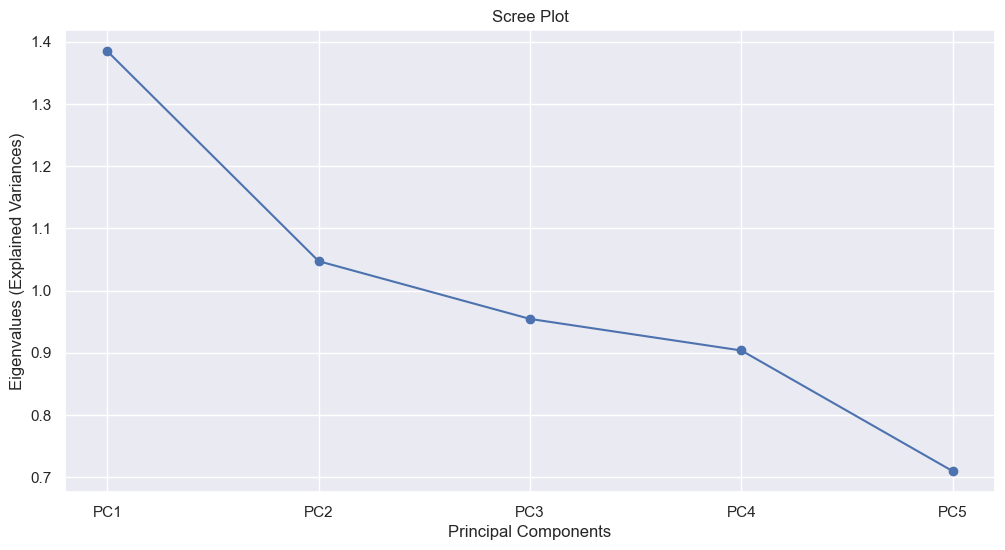

In [86]:
# Scree Plot
plt.figure(figsize = (12, 6))
# Creating a new column of principal component names in the eigenvalues dataframe. 
df_eigenval_y['Principal Components'] = principal_compo.columns

# Creating the plot
plt.plot(df_eigenval_y['Principal Components'], df_eigenval_y['Eigenvalues'], marker = 'o')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalues (Explained Variances)')
plt.title('Scree Plot')

plt.show()

Generally, the scree plot has an 'L' shape in which, after the corner, the principal components starts becoming insignificant. In the present case, since the original data were uncorrelated so we obeserve all principal components explaining similar variances. This is because due to low correlation/covariance in the data, the covariance matrix (correlation matrix for the unstandardized data) has very small values in the off-diagonal places. This way, the covariance matrix is close to a diagonal matrix whose eigenvalues are the elements on the diagonal. This explains why the eignevalues are very close to each other and hence all principal components explain similar variances. I do not expect to see this in the actual yield data that I am going to work with in suqsequents cells.  

**Working With Actual Data from FRED: Downloading and Basic Editing**

Now I am going to work with the real data. I am going to work with FRED data for government securities with maturities of 1-month, 6-months, 1-year, 3-years, and 5-years. The time period of analysis is from 2024-10-11 to 2025-04-11

In [15]:
# Downloading data using Fred API
fred = Fred(api_key='f332f4006d538e061de276c3a5376dec') # Initializing the API key
series_ids = ['DGS1MO', 'DGS6MO', 'DGS1', 'DGS3', 'DGS5'] # Setting a list of series ids
def get_yield_data(series_id): # Defining a function to fetch yields data
        return fred.get_series(series_id, observation_start = '2024-10-11', observation_end = '2025-04-11')
    

In [16]:
# Converting data into pandas dataframe
yields_dict = {series_id: get_yield_data(series_id) for series_id in series_ids}
yields = pd.DataFrame(yields_dict)
yields.columns = ['1 Month', '6 Month', '1 Year', '3 Year','5 Year']
yields.index = pd.to_datetime(yields.index)

In [17]:
yields.to_csv('gwp_fred_data.csv') # saving the file locally
yields.head()

,1 Month,6 Month,1 Year,3 Year,5 Year
2024-10-11,4.97,4.44,4.18,3.85,3.88
2024-10-14,NaN,NaN,NaN,NaN,NaN
2024-10-15,4.93,4.42,4.18,3.86,3.86
2024-10-16,4.91,4.42,4.17,3.84,3.84
2024-10-17,4.93,4.45,4.21,3.89,3.90


In [88]:
# Removing missing values
yields = yields.dropna()
yields.head() 

,1 Month,6 Month,1 Year,3 Year,5 Year
2024-10-11,4.97,4.44,4.18,3.85,3.88
2024-10-15,4.93,4.42,4.18,3.86,3.86
2024-10-16,4.91,4.42,4.17,3.84,3.84
2024-10-17,4.93,4.45,4.21,3.89,3.90
2024-10-18,4.92,4.45,4.19,3.86,3.88


In [91]:
yields.pct_change().dropna() * 100

,1 Month,6 Month,1 Year,3 Year,5 Year
2024-10-15,-0.804829,-0.450450,0.000000,0.259740,-0.515464
2024-10-16,-0.405680,0.000000,-0.239234,-0.518135,-0.518135
2024-10-17,0.407332,0.678733,0.959233,1.302083,1.562500
2024-10-18,-0.202840,0.000000,-0.475059,-0.771208,-0.512821
2024-10-21,0.000000,0.449438,1.193317,2.331606,2.577320
...,...,...,...,...,...
2025-04-07,0.000000,0.000000,0.000000,1.639344,2.688172
2025-04-08,0.000000,0.000000,-0.777202,-0.268817,1.570681
2025-04-09,0.000000,2.173913,5.221932,5.390836,4.639175
2025-04-10,0.000000,-1.418440,-1.488834,-1.534527,-0.492611


In [19]:
# Calculating daily percentage change. I will be running PCA on the daily percentage change rather than the yield itself. Yields chages are likely to be more stationary than the raw yield and hence PCA will be more meaningful.
daily_yields_change = yields.pct_change() # In proportion
daily_yields_change = daily_yields_change * 100 # The values are in percentages.
daily_yields_change = daily_yields_change.dropna() # Dropping missing values
daily_yields_change.head()

,1 Month,6 Month,1 Year,3 Year,5 Year
2024-10-15,-0.804829,-0.450450,0.000000,0.259740,-0.515464
2024-10-16,-0.405680,0.000000,-0.239234,-0.518135,-0.518135
2024-10-17,0.407332,0.678733,0.959233,1.302083,1.562500
2024-10-18,-0.202840,0.000000,-0.475059,-0.771208,-0.512821
2024-10-21,0.000000,0.449438,1.193317,2.331606,2.577320


Since PCA relies on the convariance matrix of the original data matrix, it is important that the columns, representing a time series each, be stationary. Stationary means the mean and variance does not change with time. If these change in a time series then its covariance matrix does not have much meanign and by extension, the PCA does not have much meaning. 

**Standardizing the Data**

In [20]:
# Standardizing the daily yield change
daily_yields_change_stand = (daily_yields_change - daily_yields_change.mean())/daily_yields_change.std()
daily_yields_change_stand.head()

,1 Month,6 Month,1 Year,3 Year,5 Year
2024-10-15,-1.521224,-0.815440,0.025129,0.157231,-0.397225
2024-10-16,-0.655464,0.083833,-0.231579,-0.391730,-0.399051
2024-10-17,1.107966,1.438847,1.054426,0.892832,1.023995
2024-10-18,-0.215503,0.083833,-0.484630,-0.570329,-0.395417
2024-10-21,0.224459,0.981086,1.305609,1.619385,1.718080


**Heatmap and Covariance Matrix**

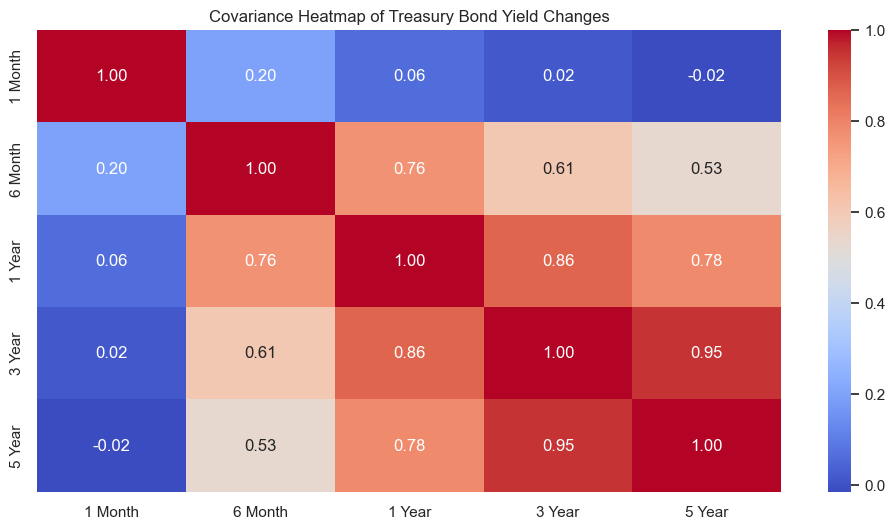

In [92]:
# Estimating covariance of the standardized data which means the correlation of the unstandardized data.
plt.figure(figsize = (12, 6))
cov_mat = daily_yields_change_stand.cov()
sns.heatmap(cov_mat, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title ('Covariance Heatmap of Treasury Bond Yield Changes')
plt.show()

In [22]:
# Daily yield change covariance matrix.
cov_mat

,1 Month,6 Month,1 Year,3 Year,5 Year
1 Month,1.000000,0.197910,0.060868,0.016244,-0.015475
6 Month,0.197910,1.000000,0.764677,0.606806,0.528154
1 Year,0.060868,0.764677,1.000000,0.863095,0.781960
3 Year,0.016244,0.606806,0.863095,1.000000,0.950546
5 Year,-0.015475,0.528154,0.781960,0.950546,1.000000


**Eigenvalues and Eigenvector Estimation and Sorting in Descending Order**

In [23]:
# Estimating eigenvalue and eigenvectors and sorting them in descending order.
yield_eigenval, yield_eigenvec = LA.eig(cov_mat)
srt_idx = np.argsort(yield_eigenval)[::-1] # [::-1] is for descending order
yield_eigenval_sorted = yield_eigenval[srt_idx]
yield_eigenvec_sorted = yield_eigenvec[:,srt_idx]
yield_eigenval_sorted


array([3.26942261, 1.05209083, 0.50395141, 0.13816685, 0.0363683 ])

**Estimation of Principal Components**

In [24]:
# Estimating principal components
yield_princi_compo = daily_yields_change_stand.dot(yield_eigenvec_sorted)

In [25]:
# Renaming the principal component columns
yield_princi_compo.columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
yield_princi_compo.head()

,PC1,PC2,PC3,PC4,PC5
2024-10-15,-0.541681,-1.588555,-0.017938,0.473170,-0.347948
2024-10-16,-0.526103,-0.477312,-0.542196,-0.066101,0.005222
2024-10-17,2.227168,1.102876,-0.140131,-0.200800,0.137212
2024-10-18,-0.727663,-0.038316,-0.412984,-0.245229,0.091154
2024-10-21,2.843315,-0.060072,0.424253,-0.148744,0.039579


In [26]:
# The variance explained by each component is equal to its eigenvalue
[yield_princi_compo['PC1'].var(), yield_princi_compo['PC2'].var(), yield_princi_compo['PC3'].var(), yield_princi_compo['PC4'].var(), yield_princi_compo['PC5'].var()]

[3.2694226135040787,
 1.0520908264890039,
 0.5039514087537769,
 0.13816685385716207,
 0.03636829739597977]

**Calculation of Variance Explained in the Direction of Each Principal Component**

In [95]:
# Calculation of Variance explained. The variance along a principal component is equal to the eigenvalue of the that principal component.
df_yield_eigenval = pd.DataFrame({'Eigenvalues': yield_eigenval_sorted}, index = range(1,6)) # converting the array of eigenvalues into a data frame whose column is called 'Eigenvalues' and rows are numbered 1 through 5.

df_yield_eigenval['Proportion Explained'] = df_yield_eigenval['Eigenvalues']/np.sum(df_yield_eigenval['Eigenvalues']) # Appending a new column of proportion of variance explained. 
df_yield_eigenval['Cumulative Proportion'] = df_yield_eigenval['Proportion Explained'].cumsum()
df_yield_eigenval.style.format({'Proportion Explained': '{:.2%}', 'Cumulative Proportion' : '{:.2%}'}) # ':'starts the format specification, '.2' means two decimal places and '%' means to add percentage sign after multiplying the result with 100. 

,Eigenvalues,Proportion Explained,Cumulative Proportion
1,3.269423,65.39%,65.39%
2,1.052091,21.04%,86.43%
3,0.503951,10.08%,96.51%
4,0.138167,2.76%,99.27%
5,0.036368,0.73%,100.00%


**Scree Plot**

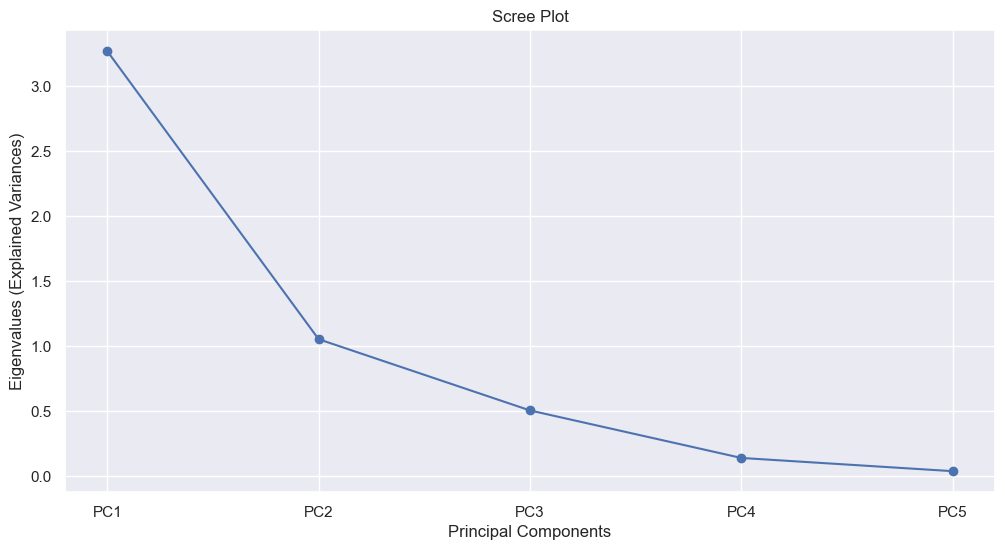

In [87]:
# Scree Plot
plt.figure(figsize = (12, 6))
# Creating a new column of principal component names in the eigenvalues dataframe. 
df_yield_eigenval['Principal Components'] = yield_princi_compo.columns

# Creating the plot
plt.plot(df_yield_eigenval['Principal Components'], df_yield_eigenval['Eigenvalues'], marker = 'o')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalues (Explained Variances)')
plt.title('Scree Plot')
plt.show()

Since the daily yield change data matrix has significant correlation among its columns, such as between 1 year and 6 months or 3 years or 5 years etc, the variance explained by different principal components has significant differences. The first principal component, represented by the first eigenvector belonging to the first eigenvalue ($3.243956$) has the maximum variance along its direction ($64.88\%$) followed by others. The first three principal components account for more than 95% of the variance.

This screeplot has a somewhat 'L' shape because the first 3 principal componnets explain most of the variance.

The first 3 principal components account for around 95% of the variability in the data. They have the following interpretation
* **PC1**: This represents a parallel shift up or down of the entire yield curve. When macro shocks hit (like an inflation print or an unexpected Fed rate hike), all yields tend to move in the same direction by roughly the same magnitude.
* **PC2**: This represents the twisting, steepening, or flattening of the curve. It captures scenarios where short-term rates rise fast (due to monetary tightening) while long-term rates stay anchored, causing the curve to flatten or invert.
* **PC3**: This represents the bending of the curve. It captures situations where medium-term rates (like the 5-Year) move independently of the short-term and long-term anchoring points, making the curve more bowed or U-shaped. 